In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch
import warnings
warnings.filterwarnings('ignore')

# Use Apple GPU (MPS) if available, fall back to CPU
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f"Using device: {device}")

data_dir = "/Users/aaditya/VS Code/1000 genome project/Code/"
out_dir  = "/Users/aaditya/VS Code/1000 genome project/Output /"

df_af       = pd.read_csv(data_dir + "chrX_AF_by_population.csv")
df_variants = pd.read_csv(data_dir + "chrX_variant_summary_qc.csv")

pop_cols = ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']

# Load the full AF matrix onto the GPU once — reused by FST and PCA
af_tensor = torch.tensor(df_af[pop_cols].values, dtype=torch.float32).to(device)  # (n_variants, 5)

print(f"Variants loaded : {len(df_variants):,}")
print(f"AF tensor shape : {af_tensor.shape}  on {af_tensor.device}")
print(df_variants.head())

Using device: mps
Variants loaded : 3,437,097
AF tensor shape : torch.Size([3437097, 5])  on mps:0
  #CHROM    POS ID REF ALT  QUAL  call_rate        AF
0      X  60026  .   T   C   100        1.0  0.004992
1      X  60032  .   T   C   100        1.0  0.005591
2      X  60052  .   T   A   100        1.0  0.315895
3      X  60057  .   G   C   100        1.0  0.000200
4      X  60060  .   G   C   100        1.0  0.048922



1. DIVERSITY METRICS
--------------------------------------------------------------------------------
     avg_heterozygosity  private_variants  n_polymorphic
AFR            0.037248          287209.0       654892.0
AMR            0.026049           17143.0       424389.0
EAS            0.021284           42651.0       301958.0
EUR            0.023431           27341.0       333450.0
SAS            0.024555           50805.0       356783.0


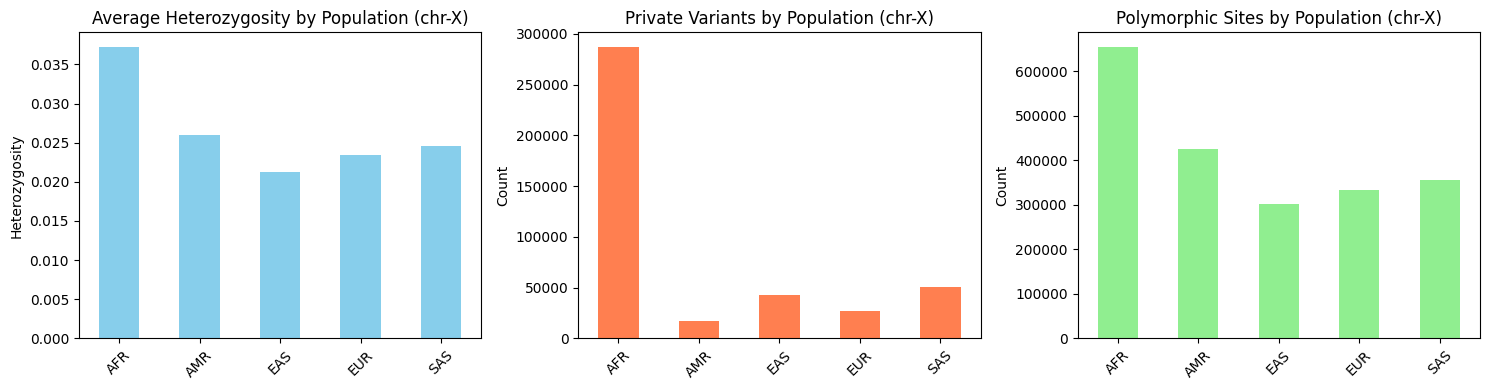

In [11]:
# ============================================================================
# 1. DIVERSITY METRICS
# ============================================================================
print("\n1. DIVERSITY METRICS")
print("-"*80)

def population_diversity(df):
    results = {}
    for pop in pop_cols:
        af = df[pop].values
        heterozygosity  = 2 * af * (1 - af)
        other_pops      = [c for c in pop_cols if c != pop]
        private_mask    = (df[pop] > 0.01) & (df[other_pops].max(axis=1) < 0.01)
        results[pop] = {
            'avg_heterozygosity': np.nanmean(heterozygosity),
            'private_variants'  : int(private_mask.sum()),
            'n_polymorphic'     : int(np.sum(af > 0.01)),
        }
    return pd.DataFrame(results).T

diversity = population_diversity(df_af)
print(diversity)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
diversity['avg_heterozygosity'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Average Heterozygosity by Population (chr-X)')
axes[0].set_ylabel('Heterozygosity')
axes[0].tick_params(axis='x', rotation=45)

diversity['private_variants'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Private Variants by Population (chr-X)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

diversity['n_polymorphic'].plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Polymorphic Sites by Population (chr-X)')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(out_dir + 'chrX_diversity_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


2. POPULATION DIFFERENTIATION
--------------------------------------------------------------------------------

Pairwise FST Matrix:
          AFR       AMR       EAS       EUR       SAS
AFR  0.000000  0.082112  0.120961  0.103834  0.094349
AMR  0.082112  0.000000  0.040073  0.025322  0.022685
EAS  0.120961  0.040073  0.000000  0.075223  0.038186
EUR  0.103834  0.025322  0.075223  0.000000  0.028855
SAS  0.094349  0.022685  0.038186  0.028855  0.000000


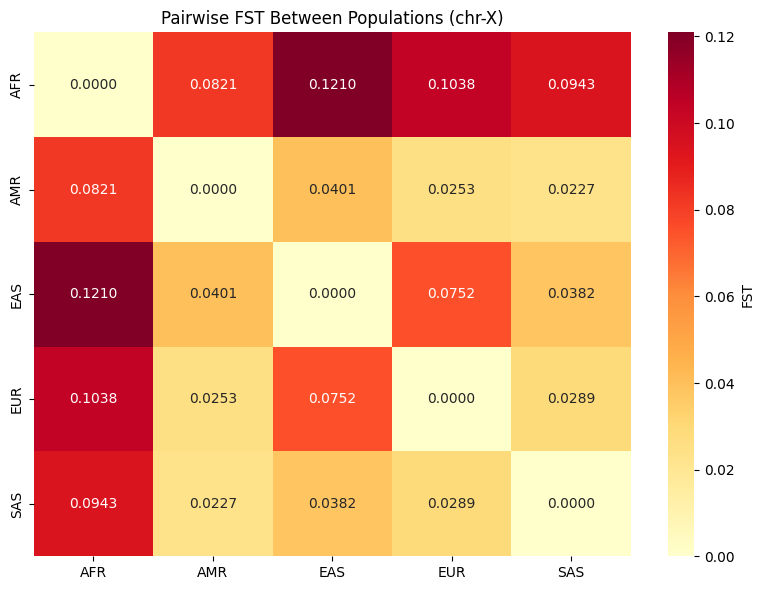


PCA variance explained: PC1=91.0%, PC2=5.5%


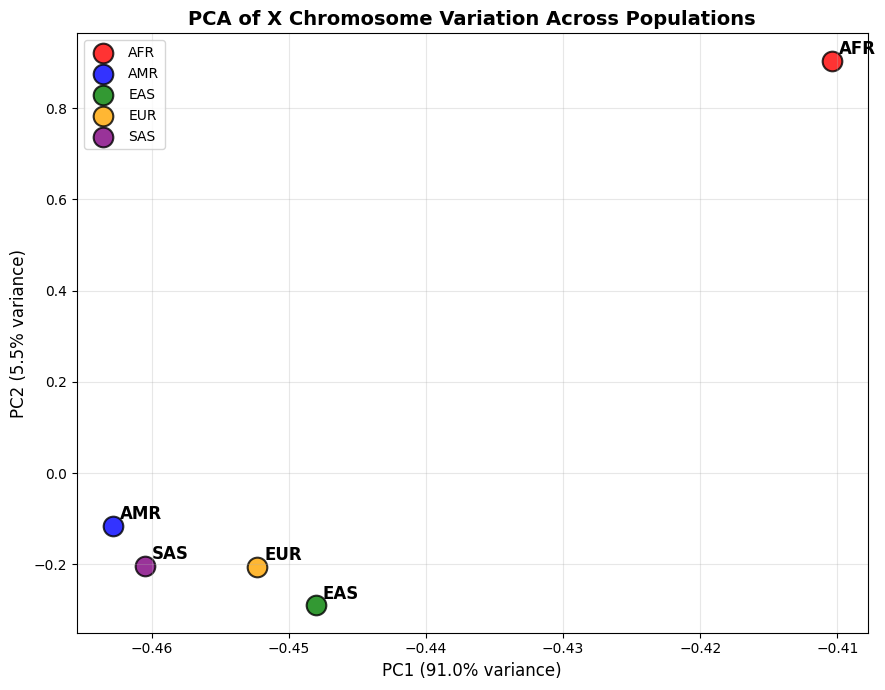

In [12]:
# ============================================================================
# 2. POPULATION DIFFERENTIATION — FST (GPU) & PCA (GPU)
# ============================================================================
print("\n2. POPULATION DIFFERENTIATION")
print("-"*80)

# --- FST on GPU ---
# af_tensor shape: (n_variants, n_pops)
n_pops = len(pop_cols)
fst_vals = torch.zeros(n_pops, n_pops, device=device)

for i in range(n_pops):
    for j in range(n_pops):
        if i == j:
            continue
        p1 = af_tensor[:, i]
        p2 = af_tensor[:, j]
        mask = ~(torch.isnan(p1) | torch.isnan(p2))
        p1m, p2m = p1[mask], p2[mask]
        pt    = (p1m + p2m) / 2
        ht    = 2 * pt * (1 - pt)
        hs    = (2 * p1m * (1 - p1m) + 2 * p2m * (1 - p2m)) / 2
        denom = ht.mean()
        fst_vals[i, j] = torch.clamp((ht - hs).mean() / denom, min=0.0) if denom > 0 else 0.0

fst_np     = fst_vals.cpu().numpy()
fst_matrix = pd.DataFrame(fst_np, index=pop_cols, columns=pop_cols)

print("\nPairwise FST Matrix:")
print(fst_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(fst_matrix.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', cbar_kws={'label': 'FST'})
plt.title('Pairwise FST Between Populations (chr-X)')
plt.tight_layout()
plt.savefig(out_dir + 'chrX_fst_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# --- PCA on GPU using torch.linalg.svd ---
# Transpose: (n_pops, n_variants) — populations are "samples" for PCA
X = af_tensor.T                                      # (5, n_variants)

# Standardise per population (row-wise)
X_mean   = X.nanmean(dim=1, keepdim=True)
X_std    = torch.sqrt(((X - X_mean) ** 2).nanmean(dim=1, keepdim=True))
X_scaled = (X - X_mean) / (X_std + 1e-8)
X_scaled = torch.nan_to_num(X_scaled, nan=0.0)      # fill residual NaNs with 0

# SVD — U columns are principal component directions for populations
U, S, Vh = torch.linalg.svd(X_scaled, full_matrices=False)

pca_result      = U[:, :2].cpu().numpy()             # (5, 2) — scores per population
explained_var   = (S[:2] ** 2 / (S ** 2).sum()).cpu().numpy()

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=pop_cols)
print(f"\nPCA variance explained: PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%}")

colors = {'AFR': 'red', 'AMR': 'blue', 'EAS': 'green', 'EUR': 'orange', 'SAS': 'purple'}
plt.figure(figsize=(9, 7))
for pop in pop_cols:
    plt.scatter(pca_df.loc[pop, 'PC1'], pca_df.loc[pop, 'PC2'],
                c=colors[pop], s=200, label=pop, alpha=0.8,
                edgecolors='black', linewidth=1.5)
    plt.annotate(pop, (pca_df.loc[pop, 'PC1'], pca_df.loc[pop, 'PC2']),
                 fontsize=12, fontweight='bold', xytext=(5, 5), textcoords='offset points')
plt.xlabel(f'PC1 ({explained_var[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]:.1%} variance)', fontsize=12)
plt.title('PCA of X Chromosome Variation Across Populations', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir + 'chrX_pca_plot.png', dpi=300, bbox_inches='tight')
plt.show()


3. RARE VS COMMON VARIANTS ANALYSIS
--------------------------------------------------------------------------------
     Rare (< 1%)  Common (> 5%)  Low Frequency (1-5%)
AFR      2779510         387344                270243
AMR      3010014         255762                171321
EAS      3132445         224625                 80027
EUR      3100952         238691                 97454
SAS      3077620         247060                112417


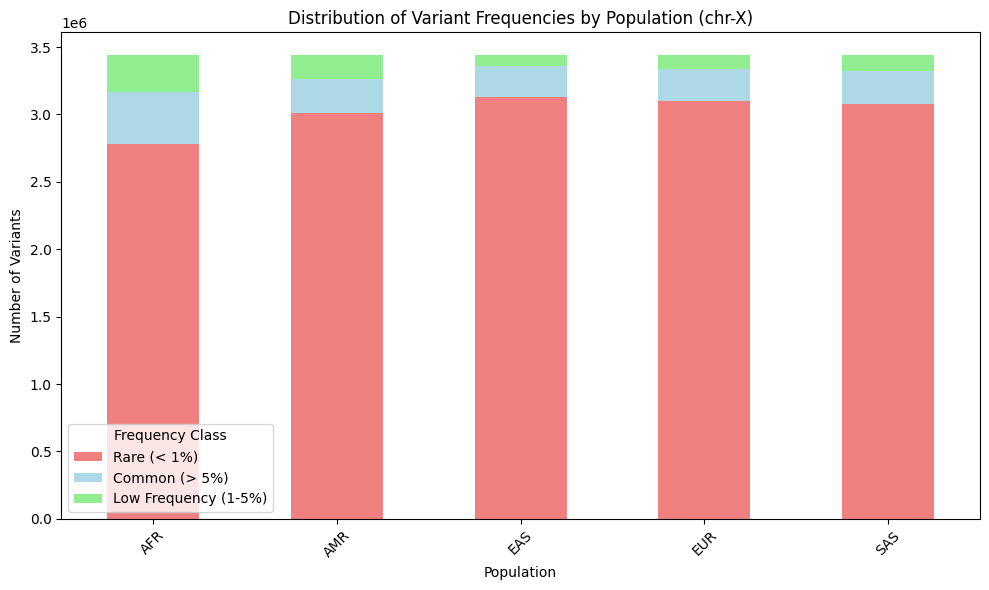

In [13]:
# ============================================================================
# 3. RARE vs COMMON VARIANTS
# ============================================================================
print("\n3. RARE VS COMMON VARIANTS ANALYSIS")
print("-"*80)

def classify_variants(af):
    if   af < 0.01: return 'Rare (< 1%)'
    elif af < 0.05: return 'Low Frequency (1-5%)'
    else:           return 'Common (> 5%)'

variant_classes = {}
for pop in pop_cols:
    variant_classes[pop] = df_af[pop].apply(classify_variants).value_counts()

variant_class_df = pd.DataFrame(variant_classes).T.fillna(0)
print(variant_class_df)

variant_class_df.plot(kind='bar', stacked=True, figsize=(10, 6),
                      color=['lightcoral', 'lightblue', 'lightgreen'])
plt.title('Distribution of Variant Frequencies by Population (chr-X)')
plt.xlabel('Population'); plt.ylabel('Number of Variants')
plt.legend(title='Frequency Class'); plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(out_dir + 'chrX_variant_frequency_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


4. SELECTION ANALYSIS
--------------------------------------------------------------------------------
AFR: Tajima's D = -0.185
AMR: Tajima's D = -0.171
EAS: Tajima's D = -0.177
EUR: Tajima's D = -0.160
SAS: Tajima's D = -0.174


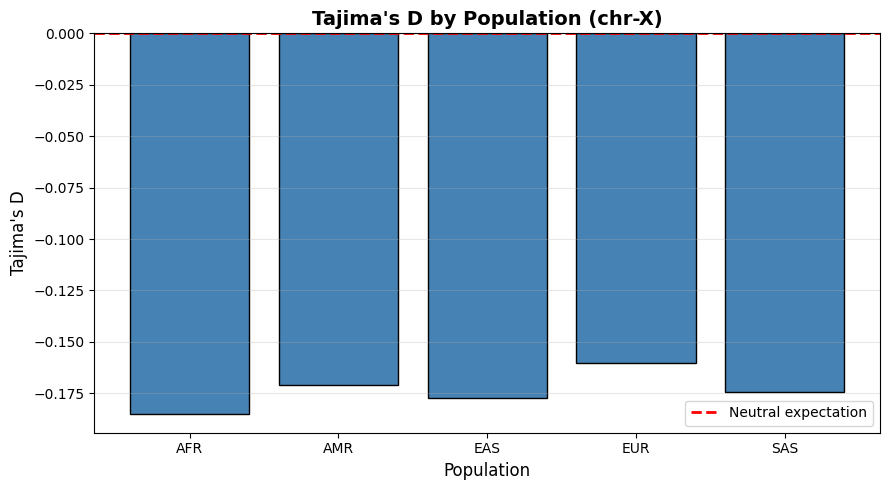


Top 10 variants with largest inter-population AF differences:
               POS ID REF ALT        AF
2441053  109036952  .   G   A  0.552716
1452173   66124916  .   G   A  0.673722
1452039   66119573  .   C   G  0.673522
1449464   66032126  .   G   A  0.674321
1449478   66032609  .   T   C  0.674321
1449517   66033986  .   G   A  0.673522
1449520   66034137  .   T   G  0.674321
1450572   66067646  .   G   T  0.674121
1450622   66069206  .   A   T  0.674321
1450975   66080294  .   G   A  0.674321


In [14]:
# ============================================================================
# 4. SELECTION ANALYSIS — Tajima's D
# ============================================================================
print("\n4. SELECTION ANALYSIS")
print("-"*80)

def calculate_tajimas_d(af, n_samples=250):
    af = af[(af > 0) & (af < 1)]
    if len(af) < 2:
        return np.nan
    S      = len(af)
    pi     = np.mean(2 * af * (1 - af)) * S
    a1     = sum(1 / i for i in range(1, n_samples))
    theta_w = S / a1
    e1     = (n_samples + 1) / (3 * (n_samples - 1))
    e2     = 2 * (n_samples**2 + n_samples + 3) / (9 * n_samples * (n_samples - 1))
    var_d  = e1 * S + e2 * S * (S - 1)
    return (pi - theta_w) / np.sqrt(var_d) if var_d > 0 else np.nan

tajimas_d = {}
for pop in pop_cols:
    D = calculate_tajimas_d(df_af[pop].dropna().values)
    tajimas_d[pop] = D
    print(f"{pop}: Tajima's D = {D:.3f}" if not np.isnan(D) else f"{pop}: Tajima's D = NA")

plt.figure(figsize=(9, 5))
valid_d = {k: v for k, v in tajimas_d.items() if not np.isnan(v)}
plt.bar(valid_d.keys(), valid_d.values(), color='steelblue', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Neutral expectation')
plt.xlabel('Population', fontsize=12); plt.ylabel("Tajima's D", fontsize=12)
plt.title("Tajima's D by Population (chr-X)", fontsize=14, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir + 'chrX_tajimas_d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 variants with largest inter-population AF differences:")
max_diff = df_af[pop_cols].max(axis=1) - df_af[pop_cols].min(axis=1)
top_diff = df_variants.iloc[max_diff.nlargest(10).index]
print(top_diff[['POS', 'ID', 'REF', 'ALT', 'AF']])


5. GEOGRAPHIC PATTERNS
--------------------------------------------------------------------------------


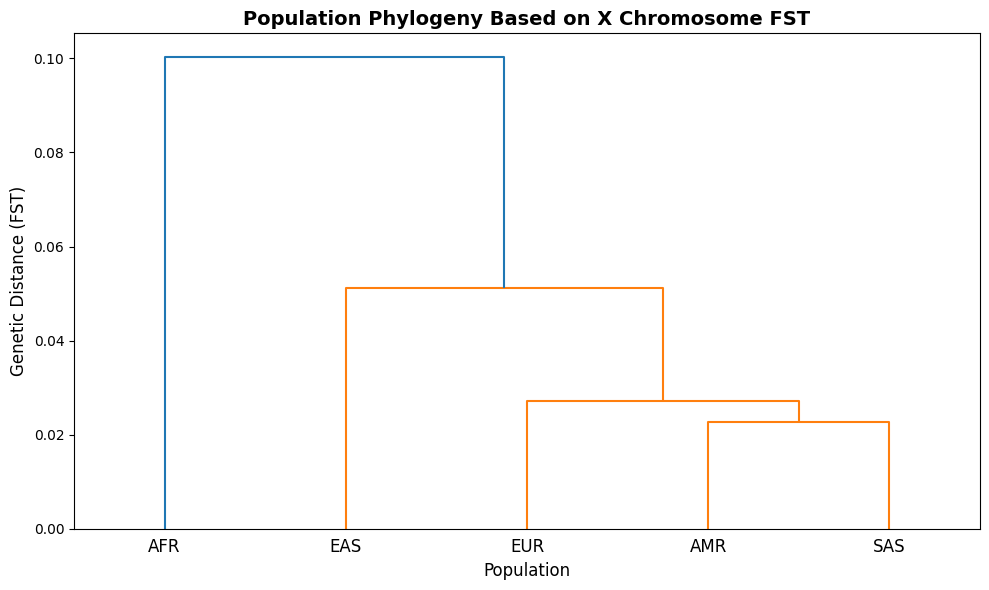

In [15]:
# ============================================================================
# 5. GEOGRAPHIC PATTERNS — Dendrogram
# ============================================================================
print("\n5. GEOGRAPHIC PATTERNS")
print("-"*80)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

fst_arr = fst_matrix.astype(float).values.copy()  # .copy() makes it writable
np.fill_diagonal(fst_arr, 0)
linkage_matrix = linkage(squareform(fst_arr), method='average')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=pop_cols, leaf_font_size=12)
plt.title('Population Phylogeny Based on X Chromosome FST', fontsize=14, fontweight='bold')
plt.xlabel('Population', fontsize=12)
plt.ylabel('Genetic Distance (FST)', fontsize=12)
plt.tight_layout()
plt.savefig(out_dir + 'chrX_population_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()


6. FUNCTIONAL ANNOTATION (Position-based)
--------------------------------------------------------------------------------

Variants by Genomic Region:
Gene
Intergenic    3367425
DMD             59272
AR               4072
FMR1             2363
MECP2            1983
HPRT1            1035
XIST              619
G6PD              328
Name: count, dtype: int64


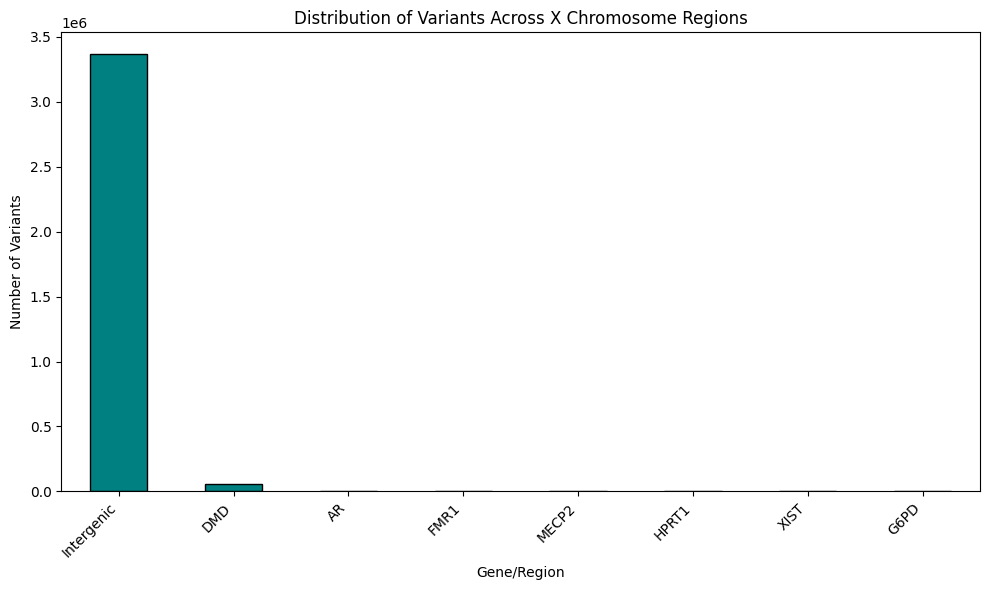


Total functional variants in genes: 69672
             POS Gene REF ALT        AF
722654  31094980  DMD   G   A  0.000998
722655  31095003  DMD   T   C  0.000799
722656  31095009  DMD   A   C  0.000399
722657  31095018  DMD   G   A  0.000200
722658  31095063  DMD   A   G  0.000399
722659  31095115  DMD   T   C  0.000200
722660  31095117  DMD   T   A  0.001597
722661  31095149  DMD   A   G  0.000200
722662  31095159  DMD   A   G  0.000200
722663  31095215  DMD   C   G  0.000399


In [16]:
# ============================================================================
# 6. FUNCTIONAL ANNOTATION — Major X-linked genes
# ============================================================================
print("\n6. FUNCTIONAL ANNOTATION (Position-based)")
print("-"*80)

# Key X chromosome gene regions (GRCh37/hg19 coordinates)
x_genes = {
    'DMD'    : (31094932,  33339609),   # Duchenne muscular dystrophy
    'AR'     : (66763874,  66950461),   # Androgen receptor
    'HPRT1'  : (134452863, 134508773),  # Lesch-Nyhan syndrome
    'MECP2'  : (154021573, 154137103),  # Rett syndrome
    'FMR1'   : (147911919, 148030048),  # Fragile-X syndrome
    'G6PD'   : (154531391, 154547572),  # G6PD deficiency
    'XIST'   : (73040485,  73072588),   # X inactivation
}

def annotate_position(pos):
    for gene, (start, end) in x_genes.items():
        if start <= pos <= end:
            return gene
    return 'Intergenic'

if 'POS' in df_variants.columns:
    df_variants['Gene'] = df_variants['POS'].astype(int).apply(annotate_position)
    gene_counts = df_variants['Gene'].value_counts()
    print("\nVariants by Genomic Region:")
    print(gene_counts)

    plt.figure(figsize=(10, 6))
    gene_counts.plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Distribution of Variants Across X Chromosome Regions')
    plt.xlabel('Gene/Region'); plt.ylabel('Number of Variants')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(out_dir + 'chrX_functional_annotation.png', dpi=300, bbox_inches='tight')
    plt.show()

    functional = df_variants[df_variants['Gene'] != 'Intergenic']
    print(f"\nTotal functional variants in genes: {len(functional)}")
    if len(functional) > 0:
        print(functional.head(10)[['POS', 'Gene', 'REF', 'ALT', 'AF']])

In [17]:
# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("\n" + "="*80)
print("X CHROMOSOME ANALYSIS SUMMARY")
print("="*80)

fst_values, fst_pairs = [], []
for i, pop1 in enumerate(pop_cols):
    for j, pop2 in enumerate(pop_cols):
        if i < j:
            fst_values.append(float(fst_matrix.loc[pop1, pop2]))
            fst_pairs.append((pop1, pop2))

max_idx = int(np.argmax(fst_values))
min_idx = int(np.argmin(fst_values))

has_functional = 'Gene' in df_variants.columns
n_functional   = len(df_variants[df_variants['Gene'] != 'Intergenic']) if has_functional else 0

summary = f"""
1. DIVERSITY METRICS:
   - Highest heterozygosity: {diversity['avg_heterozygosity'].idxmax()}
   - Most private variants : {diversity['private_variants'].idxmax()}

2. POPULATION DIFFERENTIATION:
   - Most differentiated : {fst_pairs[max_idx][0]} vs {fst_pairs[max_idx][1]} (FST={fst_values[max_idx]:.4f})
   - Least differentiated: {fst_pairs[min_idx][0]} vs {fst_pairs[min_idx][1]} (FST={fst_values[min_idx]:.4f})

3. VARIANT FREQUENCY:
   - Total rare variants  : {variant_class_df['Rare (< 1%)'].sum():.0f}
   - Total common variants: {variant_class_df['Common (> 5%)'].sum():.0f}

4. SELECTION SIGNALS:
   - Populations showing selection (|D| > 1): {[k for k, v in tajimas_d.items() if not np.isnan(v) and abs(v) > 1]}

5. GEOGRAPHIC PATTERNS:
   - See dendrogram for population relationships
   - PCA explains {explained_var[0]:.1%} + {explained_var[1]:.1%} = {explained_var.sum():.1%} of variance

6. FUNCTIONAL VARIANTS:
   - Variants in X-linked genes: {n_functional}
   - Total variants analysed   : {len(df_variants):,}
"""

print(summary)

with open(out_dir + 'chrX_analysis_summary.txt', 'w') as f:
    f.write(summary)

print("Output files saved to:", out_dir)
print("="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


X CHROMOSOME ANALYSIS SUMMARY

1. DIVERSITY METRICS:
   - Highest heterozygosity: AFR
   - Most private variants : AFR

2. POPULATION DIFFERENTIATION:
   - Most differentiated : AFR vs EAS (FST=0.1210)
   - Least differentiated: AMR vs SAS (FST=0.0227)

3. VARIANT FREQUENCY:
   - Total rare variants  : 15100541
   - Total common variants: 1353482

4. SELECTION SIGNALS:
   - Populations showing selection (|D| > 1): []

5. GEOGRAPHIC PATTERNS:
   - See dendrogram for population relationships
   - PCA explains 91.0% + 5.5% = 96.5% of variance

6. FUNCTIONAL VARIANTS:
   - Variants in X-linked genes: 69672
   - Total variants analysed   : 3,437,097

Output files saved to: /Users/aaditya/VS Code/1000 genome project/Output /
ANALYSIS COMPLETE!
